In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_csv(os.path.join('../data', 'merged_covid_and_opinion_data.csv'), parse_dates=['Day'], index_col='Day')
idx = data.index[data.notna().all(axis=1)] # Pick date range where all the opinion/cases are available
data["New_Cases"] = data.loc[idx, 'daily-new-confirmed-covid-19-cases-per-million-people'].rolling(window=7).mean()
data["New_Deaths"] = data.loc[idx, 'daily-new-confirmed-covid-19-deaths-per-million-people'].rolling(window=7).mean()
data = data.drop(["daily-new-confirmed-covid-19-cases-per-million-people","daily-new-confirmed-covid-19-deaths-per-million-people"], axis = 1)

In [ ]:
def standardize(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()

def draw(df: pd.DataFrame, cols:list[str], idx: pd.Index, opinion_col:str, shift: int = 0):
    
    if shift < 0:
        opinion = (df.loc[idx, opinion_col].shift(shift))[:shift]
        idx = idx[:shift]
    else:
        opinion = (df.loc[idx, opinion_col].shift(shift))[shift:]
        idx = idx[shift:]
        plt.plot(idx, standardize(opinion), label=opinion_col)
    for feature in cols:
        plt.plot(idx, standardize(df.loc[idx, feature]), label=feature)
    plt.legend()
    plt.show()

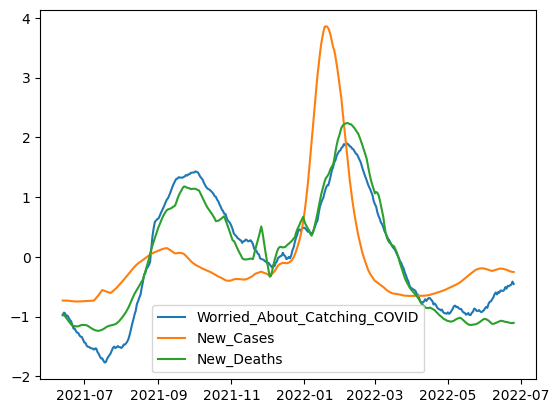

In [5]:
draw(data, ["New_Cases", "New_Deaths"], idx, "Worried_About_Catching_COVID", 24)

In [6]:
for col in data.columns:
    max = -1
    max_lag = 0
    for lag in range(-56, 56):
        if lag < 0:
            corr = np.corrcoef(data.loc[idx, col].shift(lag)[:lag], data.loc[idx, "New_Cases"][:lag])[0, 1]
        else:
            corr = np.corrcoef(data.loc[idx, col].shift(lag)[lag:], data.loc[idx, "New_Cases"][lag:])[0, 1]
        if corr > max:
            max = corr
            max_lag = lag
    print(f"Max correlation for {col}: {max} at lag {max_lag}")

Max correlation for Worried_About_Catching_COVID: 0.7212243286239317 at lag 7
Max correlation for Public_Transit: 0.09394236389589494 at lag 55
Max correlation for COVID-Like_Symptoms: 0.8574803766799658 at lag 8
Max correlation for Restaurant_Indoors: 0.15441744064467788 at lag 55
Max correlation for People_Wearing_Masks: 0.46800850680114386 at lag 6
Max correlation for COVID-Like_Symptoms_in_Community: 0.913193487261355 at lag 6
Max correlation for Anxious: 0.627735940757503 at lag 6
Max correlation for Tested_Positive: 0.7321813906583153 at lag 6
Max correlation for Shop_Indoors: 0.27397764939941854 at lag 55
Max correlation for Tested: 0.7768047805844192 at lag 6
Max correlation for COVID-19_Vaccine_Acceptance__Vaccinated_Appointment_or_Accept: 0.8615383924604078 at lag 13
Max correlation for New_Cases: -1 at lag 0
Max correlation for New_Deaths: -1 at lag 0


In [7]:
for col in data.columns:
    max = -1
    max_lag = 0
    for lag in range(-56, 56):
        if lag < 0:
            corr = np.corrcoef(data.loc[idx, col].shift(lag)[:lag], data.loc[idx, "New_Deaths"][:lag])[0, 1]
        else:
            corr = np.corrcoef(data.loc[idx, col].shift(lag)[lag:], data.loc[idx, "New_Deaths"][lag:])[0, 1]
        if corr > max:
            max = corr
            max_lag = lag
    print(f"Max correlation for {col}: {max} at lag {max_lag}")

Max correlation for Worried_About_Catching_COVID: 0.9626623107561875 at lag 24
Max correlation for Public_Transit: -0.4081035944406425 at lag 55
Max correlation for COVID-Like_Symptoms: 0.5971092517067181 at lag 28
Max correlation for Restaurant_Indoors: -0.341174651304635 at lag 55
Max correlation for People_Wearing_Masks: 0.7652885531199496 at lag 11
Max correlation for COVID-Like_Symptoms_in_Community: 0.7995623321506153 at lag 25
Max correlation for Anxious: 0.7724952332876357 at lag 19
Max correlation for Tested_Positive: 0.5789931858962956 at lag 25
Max correlation for Shop_Indoors: -0.1538256890777646 at lag 55
Max correlation for Tested: 0.6262991571228413 at lag 20
Max correlation for COVID-19_Vaccine_Acceptance__Vaccinated_Appointment_or_Accept: 0.804650938365464 at lag 34
Max correlation for New_Cases: -1 at lag 0
Max correlation for New_Deaths: -1 at lag 0


In [ ]:
for col in data.columns:
    max = -1
    max2 = -1
    max_lag = 0
    max_lag2 = 0
    opinion_change = (data.loc[idx, col] - data.loc[idx, col].shift(1))[1:]
    case_change = (data.loc[idx, "New_Deaths"] - data.loc[idx, "New_Deaths"].shift(1))[1:]
    case_derivative = (data.loc[idx, "New_Deaths"] - data.loc[idx, "New_Deaths"].shift(1))[1:]
    case_momentum = (case_derivative - case_derivative.shift(1))[1:]
    for lag in range(-28, 28):
        if lag < 0:
            corr = np.corrcoef(opinion_change.shift(lag)[:lag], case_change)[0, 1]
            corr2 = np.corrcoef(opinion_change.shift(lag)[:lag], case_momentum)[0, 1]
        else:
            corr = np.corrcoef(opinion_change.shift(lag)[lag:], case_change)[0, 1]
            corr2 = np.corrcoef(opinion_change.shift(lag)[:lag], case_momentum)[0, 1]
        if corr > max:
            max = corr
            max_lag = lag
        if corr2 > max2:
            max2 = corr2
            max_lag2 = lag
    print(f"Max correlation for {col}: {max} at lag {max_lag}")

(401,)
Day
2021-05-22         NaN
2021-05-23         NaN
2021-05-24         NaN
2021-05-25         NaN
2021-05-26         NaN
                ...   
2022-06-21    0.003585
2022-06-22   -0.008067
2022-06-23    0.009023
2022-06-24    0.007708
2022-06-25    0.009202
Name: New_Deaths, Length: 400, dtype: float64
(401,)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 373 and the array at index 1 has size 401

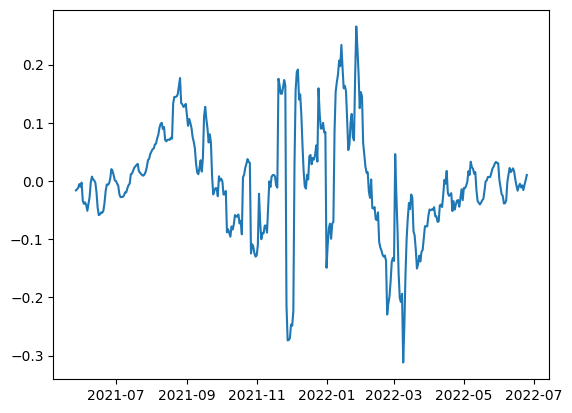

In [ ]:
case_change = (data.loc[idx, "New_Deaths"] - data.loc[idx, "New_Deaths"].shift(1))[1:]

plt.plot(idx[1:], case_change)
plt.show()